# Compact teacher redesign notebook

This notebook works from the existing 1970-start modeling panel. The purpose is to construct **persistent, binary, asset-specific teacher candidates** for **equities** and **fixed income** at **3M** and **6M** horizons, then screen them before any student modeling.

The compact version keeps all economically important definitions and diagnostics, but removes repetitive output dumps and near-duplicate visualizations.

## 1. Setup and working assumptions

The panel-building stage is already done. This notebook does **not** rebuild the raw pipeline. It loads the modeling-ready 1970-start panel and constructs candidate teachers directly from existing panel columns.

The teacher stage uses:

- equities and fixed income only,
- 3M and 6M horizons,
- binary bad/good states,
- past-only thresholding,
- explicit persistence enforcement,
- balance, persistence, and economic-separation diagnostics.

Earlier quantile labels remain benchmark-only. They are not the final target here.

In [1]:
from pathlib import Path
import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

WORKDIR = Path.cwd()
MODEL_PATH = WORKDIR / "modeling_panels" / "model_panel_start_1970_01_31.parquet"

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing modeling panel: {MODEL_PATH}")

panel = pd.read_parquet(MODEL_PATH).copy()
panel["date"] = pd.to_datetime(panel["date"])
panel = panel.sort_values("date").reset_index(drop=True)

print("Loaded:", MODEL_PATH)
print("Shape:", panel.shape)

REQUIRED_COLS = [
    "date",
    "sp500_fwd_excess_3m", "sp500_fwd_excess_6m",
    "bond_fwd_excess_3m", "bond_fwd_excess_6m",
    "sprtrn_sp500",
    "agg_ret",
    "credit_spread_baa_aaa",
    "GS10",
]

missing = [c for c in REQUIRED_COLS if c not in panel.columns]
if missing:
    raise RuntimeError(f"Missing required columns: {missing}")

ALIASES = {
    "eq_fwd_excess_3m": "sp500_fwd_excess_3m",
    "eq_fwd_excess_6m": "sp500_fwd_excess_6m",
    "fi_fwd_excess_3m": "bond_fwd_excess_3m",
    "fi_fwd_excess_6m": "bond_fwd_excess_6m",
    "eq_ret_1m": "sprtrn_sp500",
    "fi_ret_1m": "agg_ret",
    "spread_proxy": "credit_spread_baa_aaa",
    "yield_proxy": "GS10",
}

for c in REQUIRED_COLS:
    if c != "date":
        panel[c] = pd.to_numeric(panel[c], errors="coerce")

for alias, col in ALIASES.items():
    panel[alias] = pd.to_numeric(panel[col], errors="coerce")


Loaded: d:\Marcel\Google Drive Files\onedrive migration\YEAR 202526\ML IN FINANCE AND COMPLEX SYSTEMS\Bayesian-Macro-Regime-Mapping\labeling demo\modeling_panels\model_panel_start_1970_01_31.parquet
Shape: (675, 274)


## 2. Economic target definition and teacher logic

Forward return buckets were useful as a benchmark, but they are not the final teacher. The final teacher now needs to represent a **medium-horizon environment** that is:

- **persistent**: it should not flip month to month because of noise,
- **economically interpretable**: it should be clear what good and bad mean,
- **allocation-relevant**: the state should imply a plausible tilt,
- **usable later as a student target**: the rule should be transparent and stable.

Let time be indexed by $t=1,\dots,T$. Let $r_t^{\mathrm{eq}}$ be the one-month equity return and $r_t^{\mathrm{fi}}$ the one-month fixed-income return. Let $x^{\mathrm{eq}}_{t,h}$ and $x^{\mathrm{fi}}_{t,h}$ denote forward $h$-month excess returns, for $h\in\{3,6\}$.

### Base score objects

For asset $a \in \{\mathrm{eq}, \mathrm{fi}\}$ and horizon $h \in \{3,6\}$, the panel already contains the forward target primitive

$$
x^a_{t,h}.
$$

This is the core forward-looking quantity. If $x^{\mathrm{eq}}_{t,6}$ is high, then from date $t$ onward equity performs well over the next six months.

For the volatility penalty, define trailing realized volatility

$$
\sigma^a_{t,h} := \operatorname{sd}(r^a_{t-h+1}, \dots, r^a_t).
$$

This measures how unstable the asset has been recently. Economically, the same forward return is less attractive if it comes from a highly turbulent recent environment.

For equities, define trailing 12-month maximum drawdown. Inside the trailing window, form wealth,

$$
W^{\mathrm{eq}}_{t,j} := \prod_{k=t-11}^{j} (1 + r_k^{\mathrm{eq}}),
$$

the running peak,

$$
P^{\mathrm{eq}}_{t,j} := \max_{u \in \{t-11,\dots,j\}} W^{\mathrm{eq}}_{t,u},
$$

the drawdown process,

$$
D^{\mathrm{eq}}_{t,j} := \frac{W^{\mathrm{eq}}_{t,j}}{P^{\mathrm{eq}}_{t,j}} - 1,
$$

and the trailing maximum drawdown summary,

$$
DD_t^{\mathrm{eq}} := \min_{j=t-11,\dots,t} D^{\mathrm{eq}}_{t,j}.
$$

So $DD_t^{\mathrm{eq}} \le 0$, and the penalty later uses $|DD_t^{\mathrm{eq}}|$. This captures recent downside damage. Unlike volatility, it is explicitly downside-sensitive.

For bonds, let $s_t$ be the credit-spread proxy and $y_t$ the 10Y yield proxy. Their expanding past-only z-scores are

$$
z_t^s := \frac{s_t - \mu_{t-1}^s}{\tau_{t-1}^s}, \qquad z_t^y := \frac{y_t - \mu_{t-1}^y}{\tau_{t-1}^y},
$$

where $\mu_{t-1}$ and $\tau_{t-1}$ are the expanding historical mean and standard deviation computed only from observations strictly before $t$.

This matters because bond weakness can come from at least two distinct sources:

- **spread stress**: unusually wide spreads,
- **rate stress**: unusually high yields.

The z-score standardization puts both on a comparable scale.

### Continuous teacher families

For each asset-horizon pair, define a continuous score $S_{t,h,f}^a$ where $f \in \{A,B,C\}$ indexes the teacher family.

#### Equity

Family A:

$$
S_{t,h,A}^{\mathrm{eq}} := x_{t,h}^{\mathrm{eq}}.
$$

This is the pure forward-return teacher.

Family B:

$$
S_{t,h,B}^{\mathrm{eq}} := x_{t,h}^{\mathrm{eq}} - \lambda_{\mathrm{vol}}^{\mathrm{eq}} \sigma_{t,h}^{\mathrm{eq}}.
$$

This lowers the score when recent realized volatility is high.

Family C:

$$
S_{t,h,C}^{\mathrm{eq}} := x_{t,h}^{\mathrm{eq}} - \lambda_{\mathrm{dd}}^{\mathrm{eq}} |DD_t^{\mathrm{eq}}|.
$$

This penalizes recent downside damage rather than symmetric volatility. For equities that is often more natural because deep losses tend to carry stronger state information than mere choppiness.

#### Fixed income

Family A:

$$
S_{t,h,A}^{\mathrm{fi}} := x_{t,h}^{\mathrm{fi}}.
$$

Family B:

$$
S_{t,h,B}^{\mathrm{fi}} := x_{t,h}^{\mathrm{fi}} - \lambda_{\mathrm{vol}}^{\mathrm{fi}} \sigma_{t,h}^{\mathrm{fi}}.
$$

Family C:

$$
S_{t,h,C}^{\mathrm{fi}} := x_{t,h}^{\mathrm{fi}} - \lambda_{\mathrm{spread}}^{\mathrm{fi}} z_t^s - \lambda_{\mathrm{yield}}^{\mathrm{fi}} z_t^y.
$$

This decomposes bond stress into spread stress and rate stress. Economically:

- high $z_t^s$ means spreads are unusually wide,
- high $z_t^y$ means yields are unusually high,
- both push the state score downward.

### From score to binary regime

The teacher is not created by a fixed threshold. For each score process $S_t$, define a past-only expanding median threshold

$$
m_{t-1} := \operatorname{median}(S_1, \dots, S_{t-1}),
$$

using only historical information available before $t$.

Then define the raw binary state

$$
R_t := \mathbf{1}\{S_t > m_{t-1}\}.
$$

Thus “good” does not mean absolutely positive; it means **better than the asset’s own historical typical level** under that score definition.

### Persistence layer

A regime should not flip because of one isolated month. So the raw state is transformed in two steps.

First, apply a 3-month backward-looking majority vote to obtain $M_t$.

Second, enforce a minimum run length $L \in \{2,3\}$ by removing runs shorter than $L$.

The final teacher is therefore

$$
F_t^{(L)} := \mathcal{T}_L(M_t).
$$

So the full mapping is

$$
S_t \longrightarrow R_t \longrightarrow M_t \longrightarrow F_t^{(L)}.
$$

Interpretation:

- $S_t$: continuous economic score,
- $R_t$: raw above/below-history classification,
- $M_t$: locally smoothed state,
- $F_t^{(L)}$: final persistent teacher.

This is the object later student models would try to predict.

In [2]:
def trailing_vol(ret, window):
    return pd.to_numeric(ret, errors="coerce").rolling(window=window, min_periods=window).std(ddof=1)

def trailing_drawdown(ret, window):
    ret = pd.to_numeric(ret, errors="coerce")
    out = pd.Series(index=ret.index, dtype=float)
    for i in range(len(ret)):
        if i < window - 1:
            out.iloc[i] = np.nan
            continue
        win = ret.iloc[i - window + 1:i + 1]
        if win.isna().any():
            out.iloc[i] = np.nan
            continue
        wealth = (1.0 + win).cumprod()
        peak = wealth.cummax()
        dd = wealth / peak - 1.0
        out.iloc[i] = dd.min()
    return out

def zscore_expanding_past(s, min_history=60):
    s = pd.to_numeric(s, errors="coerce")
    mu = s.shift(1).expanding(min_periods=min_history).mean()
    sd = s.shift(1).expanding(min_periods=min_history).std(ddof=1)
    z = (s - mu) / sd.replace(0, np.nan)
    z[mu.isna() | sd.isna()] = np.nan
    return z

def median_threshold_state(score, min_history=60):
    score = pd.to_numeric(score, errors="coerce")
    thr = score.shift(1).expanding(min_periods=min_history).median()
    state = pd.Series(index=score.index, dtype=float)
    state[:] = np.nan
    valid = score.notna() & thr.notna()
    state.loc[valid] = (score.loc[valid] > thr.loc[valid]).astype(float)
    return state

def smooth_majority_vote(binary_state, window=3):
    s = pd.to_numeric(binary_state, errors="coerce")
    out = pd.Series(index=s.index, dtype=float)
    arr = s.to_numpy(dtype=float)
    for i in range(len(arr)):
        lo = max(0, i - window + 1)
        win = arr[lo:i + 1]
        win = win[np.isfinite(win)]
        out.iloc[i] = np.nan if len(win) == 0 else (1.0 if win.mean() >= 0.5 else 0.0)
    return out

def enforce_min_run_length(binary_state, min_run=2):
    s = pd.to_numeric(binary_state, errors="coerce")
    vals = s.to_numpy(dtype=float)
    out = vals.copy()
    n = len(vals)
    i = 0
    while i < n:
        if not np.isfinite(out[i]):
            i += 1
            continue
        j = i + 1
        while j < n and np.isfinite(out[j]) and out[j] == out[i]:
            j += 1
        run_len = j - i
        if run_len < min_run:
            prev_val = np.nan
            k = i - 1
            while k >= 0:
                if np.isfinite(out[k]):
                    prev_val = out[k]
                    break
                k -= 1
            next_val = np.nan
            k = j
            while k < n:
                if np.isfinite(out[k]):
                    next_val = out[k]
                    break
                k += 1
            fill = prev_val if np.isfinite(prev_val) else next_val
            if np.isfinite(fill):
                out[i:j] = fill
                back = i - 1
                while back >= 0 and np.isfinite(out[back]) and out[back] == fill:
                    back -= 1
                i = back + 1
                continue
        i = j
    return pd.Series(out, index=s.index)

def persistence_variant(raw_state, min_run):
    return enforce_min_run_length(smooth_majority_vote(raw_state, window=3), min_run=min_run)

def class_balance_stats(s):
    z = pd.to_numeric(s, errors="coerce").dropna().astype(int)
    if len(z) == 0:
        return {"n_obs": 0, "count_0": 0, "count_1": 0, "minority_share": np.nan}
    cnt = z.value_counts().to_dict()
    c0, c1 = cnt.get(0, 0), cnt.get(1, 0)
    return {
        "n_obs": len(z),
        "count_0": c0,
        "count_1": c1,
        "minority_share": min(c0, c1) / len(z),
    }

def persistence_stats(s):
    z = pd.to_numeric(s, errors="coerce").dropna().astype(int)
    if len(z) < 2:
        return {"switch_rate": np.nan, "same_as_lag_share": np.nan, "avg_run_length": np.nan}
    switches = (z != z.shift(1)).fillna(False)
    switch_rate = switches.iloc[1:].mean()
    same_as_lag_share = (z.iloc[1:].to_numpy() == z.iloc[:-1].to_numpy()).mean()
    runs = []
    cur = z.iloc[0]
    run = 1
    for val in z.iloc[1:]:
        if val == cur:
            run += 1
        else:
            runs.append(run)
            cur = val
            run = 1
    runs.append(run)
    return {
        "switch_rate": switch_rate,
        "same_as_lag_share": same_as_lag_share,
        "avg_run_length": float(np.mean(runs)),
    }

def train_test_balance_stats(s, test_fraction=0.25):
    z = pd.to_numeric(s, errors="coerce").dropna().astype(int)
    if len(z) == 0:
        return {}
    split = int(len(z) * (1 - test_fraction))
    tr = z.iloc[:split]
    te = z.iloc[split:]
    def one_part(x, prefix):
        cnt = x.value_counts().to_dict()
        c0, c1 = cnt.get(0, 0), cnt.get(1, 0)
        n = len(x)
        return {
            f"{prefix}_n": n,
            f"{prefix}_count_0": c0,
            f"{prefix}_count_1": c1,
            f"{prefix}_minority_share": min(c0, c1) / n if n else np.nan,
            f"{prefix}_single_class": int((c0 == 0) or (c1 == 0)),
        }
    out = {}
    out.update(one_part(tr, "train"))
    out.update(one_part(te, "test"))
    return out

def economic_separation(df, teacher_col, asset, horizon):
    if asset == "equity":
        ex_col = f"eq_fwd_excess_{horizon}m"
        vol_col = f"eq_trail_vol_{horizon}m"
        dd_col = "eq_drawdown_12m"
        extra_cols = []
    else:
        ex_col = f"fi_fwd_excess_{horizon}m"
        vol_col = f"fi_trail_vol_{horizon}m"
        dd_col = None
        extra_cols = ["spread_proxy", "yield_proxy"]
    out = {}
    for state in [0, 1]:
        mask = df[teacher_col] == state
        out[f"avg_fwd_excess_state{state}"] = df.loc[mask, ex_col].mean()
        out[f"avg_trail_vol_state{state}"] = df.loc[mask, vol_col].mean()
        if dd_col is not None:
            out[f"avg_drawdown_state{state}"] = df.loc[mask, dd_col].mean()
        for col in extra_cols:
            out[f"avg_{col}_state{state}"] = df.loc[mask, col].mean()
    out["gap_fwd_excess_good_minus_bad"] = out.get("avg_fwd_excess_state1", np.nan) - out.get("avg_fwd_excess_state0", np.nan)
    out["gap_trail_vol_good_minus_bad"] = out.get("avg_trail_vol_state1", np.nan) - out.get("avg_trail_vol_state0", np.nan)
    if dd_col is not None:
        out["gap_drawdown_good_minus_bad"] = out.get("avg_drawdown_state1", np.nan) - out.get("avg_drawdown_state0", np.nan)
    return out

def run_lengths(s):
    z = pd.to_numeric(s, errors="coerce").dropna().astype(int)
    if len(z) == 0:
        return []
    runs = []
    cur = z.iloc[0]
    run = 1
    for val in z.iloc[1:]:
        if val == cur:
            run += 1
        else:
            runs.append(run)
            cur = val
            run = 1
    runs.append(run)
    return runs

def build_index_from_returns(ret, start=100.0):
    ret = pd.to_numeric(ret, errors="coerce")
    idx = pd.Series(index=ret.index, dtype=float)
    level = start
    for i, r in enumerate(ret):
        if pd.isna(r):
            idx.iloc[i] = np.nan
        else:
            level *= (1.0 + r)
            idx.iloc[i] = level
    return idx


## 3. Build score components and candidate teacher scores

These helper series are not a second feature-engineering project. They are direct score components needed to define the teacher economically.

For bonds, spread and yield are standardized first so that one cannot dominate the other purely because of scale.

In [3]:
panel["eq_trail_vol_3m"] = trailing_vol(panel["eq_ret_1m"], 3)
panel["eq_trail_vol_6m"] = trailing_vol(panel["eq_ret_1m"], 6)
panel["eq_drawdown_12m"] = trailing_drawdown(panel["eq_ret_1m"], 12)

panel["fi_trail_vol_3m"] = trailing_vol(panel["fi_ret_1m"], 3)
panel["fi_trail_vol_6m"] = trailing_vol(panel["fi_ret_1m"], 6)

panel["spread_proxy_z"] = zscore_expanding_past(panel["spread_proxy"], min_history=60)
panel["yield_proxy_z"] = zscore_expanding_past(panel["yield_proxy"], min_history=60)

LAMBDA_EQ_VOL = 0.5
LAMBDA_EQ_DD = 0.75
LAMBDA_FI_VOL = 0.5
LAMBDA_FI_SPREAD = 0.5
LAMBDA_FI_YIELD = 0.5

for h in [3, 6]:
    panel[f"eq_score_A_{h}m"] = panel[f"eq_fwd_excess_{h}m"]
    panel[f"eq_score_B_{h}m"] = panel[f"eq_fwd_excess_{h}m"] - LAMBDA_EQ_VOL * panel[f"eq_trail_vol_{h}m"]
    panel[f"eq_score_C_{h}m"] = panel[f"eq_fwd_excess_{h}m"] - LAMBDA_EQ_DD * panel["eq_drawdown_12m"].abs()

    panel[f"fi_score_A_{h}m"] = panel[f"fi_fwd_excess_{h}m"]
    panel[f"fi_score_B_{h}m"] = panel[f"fi_fwd_excess_{h}m"] - LAMBDA_FI_VOL * panel[f"fi_trail_vol_{h}m"]
    panel[f"fi_score_C_{h}m"] = (
        panel[f"fi_fwd_excess_{h}m"]
        - LAMBDA_FI_SPREAD * panel["spread_proxy_z"]
        - LAMBDA_FI_YIELD * panel["yield_proxy_z"]
    )



## 4. Convert scores into raw teachers and persistence variants

Each score is converted into a raw binary state using a **past-only expanding median threshold**. Then each raw state is turned into two persistence variants:

- majority vote over 3 months plus minimum run length 2,
- majority vote over 3 months plus minimum run length 3.

The point is not to assume one smoothing level is automatically correct. The notebook keeps both and compares them later.

In [4]:
TEACHERS_RAW = {}
TEACHERS_FINAL = {}

def register_raw_teacher(name, series, asset, horizon, family, score_col):
    TEACHERS_RAW[name] = {
        "series": series,
        "asset": asset,
        "horizon_m": horizon,
        "family": family,
        "score_col": score_col,
    }

def register_final_teacher(name, series, asset, horizon, family, score_col, min_run):
    TEACHERS_FINAL[name] = {
        "series": series,
        "asset": asset,
        "horizon_m": horizon,
        "family": family,
        "score_col": score_col,
        "min_run": min_run,
    }

for asset_prefix, asset_name in [("eq", "equity"), ("fi", "fixed_income")]:
    for family in ["A", "B", "C"]:
        for h in [3, 6]:
            score_col = f"{asset_prefix}_score_{family}_{h}m"
            raw_name = f"{asset_prefix}_raw_{family}_{h}m"
            raw_state = median_threshold_state(panel[score_col], min_history=60)
            panel[raw_name] = raw_state
            register_raw_teacher(raw_name, raw_state, asset_name, h, family, score_col)

for raw_name, meta in TEACHERS_RAW.items():
    for min_run in [2, 3]:
        final_name = raw_name.replace("_raw_", f"_mr{min_run}_")
        final_series = persistence_variant(meta["series"], min_run=min_run)
        panel[final_name] = final_series
        register_final_teacher(
            final_name,
            final_series,
            meta["asset"],
            meta["horizon_m"],
            meta["family"],
            meta["score_col"],
            min_run,
        )

raw_cols = list(TEACHERS_RAW.keys())
final_cols = list(TEACHERS_FINAL.keys())
print(f"Raw teachers: {len(raw_cols)}")
print(f"Final teachers: {len(final_cols)}")


Raw teachers: 12
Final teachers: 24


## 5. Validation: did persistence enforcement actually work?

This is a direct sanity check. If a teacher is labeled as minimum-run-2 or minimum-run-3, then the observed minimum run in the final series should respect that rule.

In [5]:
check_rows = []
for name in TEACHERS_FINAL:
    runs = run_lengths(panel[name])
    check_rows.append({
        "teacher": name,
        "min_run_declared": TEACHERS_FINAL[name]["min_run"],
        "min_observed_run": min(runs) if len(runs) else np.nan,
        "n_runs": len(runs),
    })

run_check = pd.DataFrame(check_rows).sort_values("teacher").reset_index(drop=True)
print(run_check.to_string(index=False))


    teacher  min_run_declared  min_observed_run  n_runs
eq_mr2_A_3m                 2                 2      91
eq_mr2_A_6m                 2                 2      55
eq_mr2_B_3m                 2                 2      89
eq_mr2_B_6m                 2                 2      57
eq_mr2_C_3m                 2                 2      61
eq_mr2_C_6m                 2                 2      43
eq_mr3_A_3m                 3                 3      63
eq_mr3_A_6m                 3                 3      49
eq_mr3_B_3m                 3                 3      59
eq_mr3_B_6m                 3                 3      47
eq_mr3_C_3m                 3                 3      47
eq_mr3_C_6m                 3                 3      41
fi_mr2_A_3m                 2                 2      83
fi_mr2_A_6m                 2                 2      55
fi_mr2_B_3m                 2                 2      80
fi_mr2_B_6m                 2                 2      54
fi_mr2_C_3m                 2                 2 

## 6. Diagnostics table

Every candidate teacher gets the same diagnostic treatment.

The key diagnostics are:

- **balance**: is one class collapsing?
- **persistence**: does the state behave like a regime?
- **economic separation**: is the state labeled good actually associated with higher average forward excess return than the state labeled bad?

For a sensible teacher, the good-minus-bad forward return gap should be **positive**.

In [6]:
diag_rows = []
for name, meta in TEACHERS_FINAL.items():
    row = {
        "teacher": name,
        "asset": meta["asset"],
        "horizon_m": meta["horizon_m"],
        "family": meta["family"],
        "score_col": meta["score_col"],
        "min_run": meta["min_run"],
    }
    row.update(class_balance_stats(panel[name]))
    row.update(train_test_balance_stats(panel[name], test_fraction=0.25))
    row.update(persistence_stats(panel[name]))
    row.update(economic_separation(panel, name, meta["asset"], meta["horizon_m"]))
    diag_rows.append(row)

diag = pd.DataFrame(diag_rows).sort_values(["asset", "horizon_m", "family", "min_run"]).reset_index(drop=True)

diag_view_cols = [
    "teacher", "asset", "horizon_m", "family", "min_run",
    "n_obs", "count_0", "count_1", "minority_share",
    "switch_rate", "same_as_lag_share", "avg_run_length",
    "gap_fwd_excess_good_minus_bad", "gap_trail_vol_good_minus_bad"
]
print(diag[diag_view_cols].to_string(index=False))


    teacher        asset  horizon_m family  min_run  n_obs  count_0  count_1  minority_share  switch_rate  same_as_lag_share  avg_run_length  gap_fwd_excess_good_minus_bad  gap_trail_vol_good_minus_bad
eq_mr2_A_3m       equity          3      A        2    599      235      364        0.392321     0.150502           0.849498        6.582418                       0.083564                     -0.002136
eq_mr3_A_3m       equity          3      A        3    599      231      368        0.385643     0.103679           0.896321        9.507937                       0.084919                     -0.004866
eq_mr2_B_3m       equity          3      B        2    597      240      357        0.402010     0.147651           0.852349        6.707865                       0.077925                     -0.007301
eq_mr3_B_3m       equity          3      B        3    597      242      355        0.405360     0.097315           0.902685       10.118644                       0.078463                     

## 7. First-pass screening

The compact screen uses the same triage logic as the longer notebook:

- minority share at least 0.20,
- no single-class collapse in the test split,
- switch rate between 0.05 and 0.45,
- same-as-lag share below 0.95,
- average run length at least 2,
- good-minus-bad forward excess gap positive.

These are not final model-selection criteria. They are meant to remove clearly broken teacher constructions before the project moves to student modeling.

In [7]:
diag["pass_balance"] = (
    (diag["minority_share"] >= 0.20) &
    (diag["test_single_class"] == 0)
)

diag["pass_persistence"] = (
    diag["switch_rate"].between(0.05, 0.45, inclusive="both") &
    (diag["same_as_lag_share"] < 0.95) &
    (diag["avg_run_length"] >= 2.0)
)

diag["pass_separation"] = diag["gap_fwd_excess_good_minus_bad"] > 0
diag["survives_first_pass"] = diag["pass_balance"] & diag["pass_persistence"] & diag["pass_separation"]

screen_cols = [
    "teacher", "asset", "horizon_m", "family", "min_run",
    "minority_share", "test_single_class",
    "switch_rate", "same_as_lag_share", "avg_run_length",
    "gap_fwd_excess_good_minus_bad",
    "pass_balance", "pass_persistence", "pass_separation", "survives_first_pass"
]
print(diag[screen_cols].to_string(index=False))

survivors = diag.loc[diag["survives_first_pass"]].copy()
survivor_summary = survivors[[
    "teacher", "asset", "horizon_m", "family", "min_run",
    "minority_share", "switch_rate", "avg_run_length", "gap_fwd_excess_good_minus_bad"
]].reset_index(drop=True)
print(survivor_summary.to_string(index=False))


    teacher        asset  horizon_m family  min_run  minority_share  test_single_class  switch_rate  same_as_lag_share  avg_run_length  gap_fwd_excess_good_minus_bad  pass_balance  pass_persistence  pass_separation  survives_first_pass
eq_mr2_A_3m       equity          3      A        2        0.392321                  0     0.150502           0.849498        6.582418                       0.083564          True              True             True                 True
eq_mr3_A_3m       equity          3      A        3        0.385643                  0     0.103679           0.896321        9.507937                       0.084919          True              True             True                 True
eq_mr2_B_3m       equity          3      B        2        0.402010                  0     0.147651           0.852349        6.707865                       0.077925          True              True             True                 True
eq_mr3_B_3m       equity          3      B        3     

## 8. Minimum-run comparison

This comparison is decision-relevant because minimum-run-3 usually produces a stickier regime than minimum-run-2. The question is whether stronger smoothing improves regime quality or simply makes the state too inert.

In practice, the two are usually very similar, and the choice is mainly a persistence-versus-flexibility tradeoff.

In [8]:
mr_compare = diag[[
    "asset", "horizon_m", "family", "min_run",
    "minority_share", "switch_rate", "same_as_lag_share",
    "avg_run_length", "gap_fwd_excess_good_minus_bad", "survives_first_pass"
]].sort_values(["asset", "horizon_m", "family", "min_run"]).reset_index(drop=True)
print(mr_compare.to_string(index=False))

pair_rows = []
for asset_prefix in ["eq", "fi"]:
    for family in ["A", "B", "C"]:
        for h in [3, 6]:
            c2 = f"{asset_prefix}_mr2_{family}_{h}m"
            c3 = f"{asset_prefix}_mr3_{family}_{h}m"
            if c2 in panel.columns and c3 in panel.columns:
                mask = panel[[c2, c3]].notna().all(axis=1)
                same_share = ((panel.loc[mask, c2] == panel.loc[mask, c3]).mean() if mask.any() else np.nan)
                pair_rows.append({
                    "teacher_pair": f"{asset_prefix}_{family}_{h}m",
                    "n_overlap": int(mask.sum()),
                    "same_share_mr2_vs_mr3": same_share,
                })
pair_df = pd.DataFrame(pair_rows).sort_values("teacher_pair").reset_index(drop=True)
print(pair_df.to_string(index=False))


       asset  horizon_m family  min_run  minority_share  switch_rate  same_as_lag_share  avg_run_length  gap_fwd_excess_good_minus_bad  survives_first_pass
      equity          3      A        2        0.392321     0.150502           0.849498        6.582418                       0.083564                 True
      equity          3      A        3        0.385643     0.103679           0.896321        9.507937                       0.084919                 True
      equity          3      B        2        0.402010     0.147651           0.852349        6.707865                       0.077925                 True
      equity          3      B        3        0.405360     0.097315           0.902685       10.118644                       0.078463                 True
      equity          3      C        2        0.360544     0.102215           0.897785        9.639344                       0.058630                 True
      equity          3      C        3        0.350340     0.07

## 9. Focused visuals

We plot:

- final state against reconstructed asset path,
- score versus final state.

These are enough to check whether the teacher lines up with economically favorable and unfavorable phases.

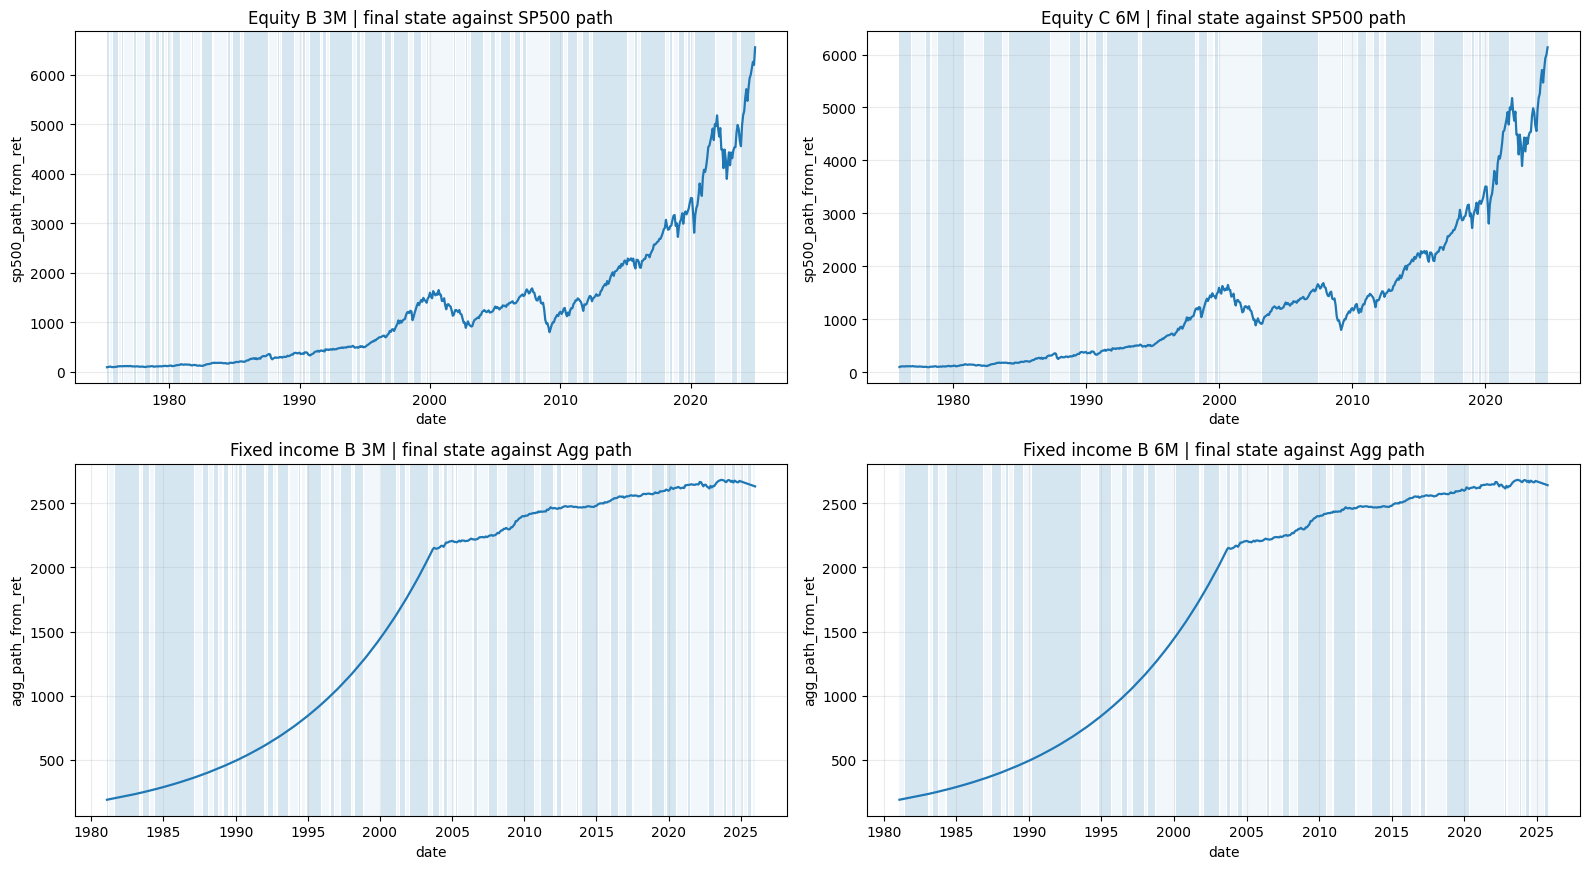

In [9]:
panel["sp500_path_from_ret"] = build_index_from_returns(panel["eq_ret_1m"], start=100.0)
panel["agg_path_from_ret"] = build_index_from_returns(panel["fi_ret_1m"], start=100.0)

def plot_teacher_path_grid(df, specs, ncols=2, figsize_per_row=4.4):
    n = len(specs)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, figsize_per_row * nrows), squeeze=False)
    axes = axes.flatten()

    for ax, (teacher_col, path_col, title) in zip(axes, specs):
        sub = df[["date", teacher_col, path_col]].copy()
        sub = sub[sub[teacher_col].notna() & sub[path_col].notna()].copy()

        if sub.empty:
            ax.set_title(f"{title}\n(no usable data)")
            ax.axis("off")
            continue

        ax.plot(sub["date"], sub[path_col], linewidth=1.6)

        state = sub[teacher_col].to_numpy()
        dates = sub["date"].to_numpy()

        start = 0
        for i in range(1, len(sub) + 1):
            boundary = (i == len(sub)) or (state[i] != state[start])
            if boundary:
                x0 = dates[start]
                x1 = dates[i - 1]

                if state[start] == 1:
                    ax.axvspan(x0, x1, alpha=0.18)
                else:
                    ax.axvspan(x0, x1, alpha=0.06)

                start = i

        ax.set_title(title)
        ax.set_xlabel("date")
        ax.set_ylabel(path_col)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

path_specs = [
    ("eq_mr2_B_3m", "sp500_path_from_ret", "Equity B 3M | final state against SP500 path"),
    ("eq_mr2_C_6m", "sp500_path_from_ret", "Equity C 6M | final state against SP500 path"),
    ("fi_mr2_B_3m", "agg_path_from_ret", "Fixed income B 3M | final state against Agg path"),
    ("fi_mr2_B_6m", "agg_path_from_ret", "Fixed income B 6M | final state against Agg path"),
]

plot_teacher_path_grid(panel, path_specs, ncols=2)

## 10. Compact conclusion and shortlist

What survives matters more than the exact numerical ranking of every candidate. The key economic result is whether the proposed binary state behaves like a usable regime and whether the “good” state actually corresponds to stronger forward returns.

This is the final shortlist for the next stage.

In [10]:
recommend_rows = []
for _, r in diag.sort_values(["asset", "horizon_m", "family", "min_run"]).iterrows():
    recommendation = "keep" if r["survives_first_pass"] else "drop"
    reason = []
    if not r["pass_balance"]:
        reason.append("balance")
    if not r["pass_persistence"]:
        reason.append("persistence")
    if not r["pass_separation"]:
        reason.append("economic separation")
    reason_text = ", ".join(reason) if reason else "passes first-pass screen"
    recommend_rows.append({
        "teacher": r["teacher"],
        "asset": r["asset"],
        "horizon_m": r["horizon_m"],
        "family": r["family"],
        "min_run": r["min_run"],
        "decision": recommendation,
        "reason": reason_text,
    })

recommend_df = pd.DataFrame(recommend_rows)

print("Main conclusion:")
print("- All equity families A/B/C survive at both 3M and 6M.")
print("- Fixed-income families A and B survive at both 3M and 6M.")
print("- Fixed-income family C fails and should be dropped.")
print("- mr3 is usually stickier than mr2, but the two are highly overlapping.")


Main conclusion:
- All equity families A/B/C survive at both 3M and 6M.
- Fixed-income families A and B survive at both 3M and 6M.
- Fixed-income family C fails and should be dropped.
- mr3 is usually stickier than mr2, but the two are highly overlapping.


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, balanced_accuracy_score, log_loss
import numpy as np
import pandas as pd

# ============================================================
# 11. Quick student-model test on surviving teacher targets
# ============================================================

TEST_FRACTION = 0.25
CV_SPLITS = 5
C_GRID = np.logspace(-4, 2, 15)
MAX_ITER = 5000
RANDOM_STATE = 42

if "survivors" not in globals() or survivors.empty:
    raise RuntimeError("No surviving teachers found. Run the screening cells first.")

teacher_targets = survivors["teacher"].tolist()

def build_l2_model(C):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=C,
            solver="lbfgs",
            max_iter=MAX_ITER,
            random_state=RANDOM_STATE,
        )),
    ])

def get_feature_cols(df, target_col):
    exclude_cols = {"date", target_col}
    for c in df.columns:
        c_low = c.lower()
        if (
            ("label" in c_low)
            or ("teacher" in c_low)
            or ("_raw_" in c_low)
            or ("_mr2_" in c_low)
            or ("_mr3_" in c_low)
            or ("score_" in c_low)
            or ("fwd_" in c_low)
            or ("forward" in c_low)
        ):
            exclude_cols.add(c)
    feature_cols = [c for c in df.columns if c not in exclude_cols]
    return feature_cols

def fit_best_l2_timeseries_cv(X_tr, y_tr):
    tscv = TimeSeriesSplit(n_splits=CV_SPLITS)
    rows = []

    for C in C_GRID:
        fold_losses = []
        for tr_idx, va_idx in tscv.split(X_tr):
            X_tr_cv = X_tr.iloc[tr_idx]
            y_tr_cv = y_tr.iloc[tr_idx]
            X_va_cv = X_tr.iloc[va_idx]
            y_va_cv = y_tr.iloc[va_idx]

            if y_tr_cv.nunique() < 2 or y_va_cv.nunique() < 2:
                continue

            model = build_l2_model(C)
            model.fit(X_tr_cv, y_tr_cv)
            proba = model.predict_proba(X_va_cv)
            fold_losses.append(log_loss(y_va_cv, proba, labels=[0, 1]))

        rows.append({
            "C": C,
            "cv_log_loss": np.mean(fold_losses) if fold_losses else np.nan,
            "n_valid_folds": len(fold_losses),
        })

    cv_df = pd.DataFrame(rows).dropna().sort_values(["cv_log_loss", "C"]).reset_index(drop=True)
    if cv_df.empty:
        raise RuntimeError("No valid CV folds were available.")
    best_C = float(cv_df.iloc[0]["C"])
    final_model = build_l2_model(best_C)
    final_model.fit(X_tr, y_tr)
    return final_model, best_C, cv_df

result_rows = []

for target_col in teacher_targets:
    feature_cols = get_feature_cols(panel, target_col)

    work = panel[["date", target_col] + feature_cols].copy()
    work = work[work[target_col].notna()].copy()
    work[target_col] = pd.to_numeric(work[target_col], errors="coerce")
    work = work[work[target_col].notna()].copy()
    work[target_col] = work[target_col].astype(int)

    if work[target_col].nunique() < 2:
        continue

    split_idx = int(len(work) * (1 - TEST_FRACTION))
    train_df = work.iloc[:split_idx].copy()
    test_df = work.iloc[split_idx:].copy()

    if train_df[target_col].nunique() < 2 or test_df[target_col].nunique() < 2:
        continue

    X_tr = train_df[feature_cols]
    y_tr = train_df[target_col]
    X_te = test_df[feature_cols]
    y_te = test_df[target_col]

    model, best_C, cv_df = fit_best_l2_timeseries_cv(X_tr, y_tr)
    proba_te = model.predict_proba(X_te)
    pred_te = model.predict(X_te)

    # persistence baseline: predict y_{t-1}
    y_te_prev = test_df[target_col].shift(1)
    valid_base = y_te_prev.notna()
    y_te_base = y_te.loc[valid_base]
    pred_base = y_te_prev.loc[valid_base].astype(int)

    # class-frequency baseline from train split
    p1 = y_tr.mean()
    p0 = 1.0 - p1
    proba_freq = np.column_stack([np.full(len(y_te), p0), np.full(len(y_te), p1)])
    pred_freq = np.where(p1 >= 0.5, 1, 0)

    result_rows.append({
        "target": target_col,
        "asset": survivors.loc[survivors["teacher"] == target_col, "asset"].iloc[0],
        "horizon_m": int(survivors.loc[survivors["teacher"] == target_col, "horizon_m"].iloc[0]),
        "family": survivors.loc[survivors["teacher"] == target_col, "family"].iloc[0],
        "min_run": int(survivors.loc[survivors["teacher"] == target_col, "min_run"].iloc[0]),
        "n_features": len(feature_cols),
        "train_n": len(train_df),
        "test_n": len(test_df),
        "best_C": best_C,

        "l2_accuracy": accuracy_score(y_te, pred_te),
        "l2_balanced_accuracy": balanced_accuracy_score(y_te, pred_te),
        "l2_log_loss": log_loss(y_te, proba_te, labels=[0, 1]),

        "persist_accuracy": accuracy_score(y_te_base, pred_base),
        "persist_balanced_accuracy": balanced_accuracy_score(y_te_base, pred_base),

        "freq_accuracy": accuracy_score(y_te, np.full(len(y_te), pred_freq)),
        "freq_balanced_accuracy": balanced_accuracy_score(y_te, np.full(len(y_te), pred_freq)),
        "freq_log_loss": log_loss(y_te, proba_freq, labels=[0, 1]),

        "l2_minus_persist_acc": accuracy_score(y_te, pred_te) - accuracy_score(y_te_base, pred_base),
        "l2_minus_freq_acc": accuracy_score(y_te, pred_te) - accuracy_score(y_te, np.full(len(y_te), pred_freq)),
        "l2_minus_freq_logloss": log_loss(y_te, proba_freq, labels=[0, 1]) - log_loss(y_te, proba_te, labels=[0, 1]),
    })

student_test_results = (
    pd.DataFrame(result_rows)
    .sort_values(["asset", "horizon_m", "family", "min_run"])
    .reset_index(drop=True)
)

view_cols = [
    "target", "asset", "horizon_m", "family", "min_run",
    "train_n", "test_n", "n_features", "best_C",
    "l2_accuracy", "l2_balanced_accuracy", "l2_log_loss",
    "persist_accuracy", "persist_balanced_accuracy",
    "freq_accuracy", "freq_balanced_accuracy", "freq_log_loss",
    "l2_minus_persist_acc", "l2_minus_freq_acc", "l2_minus_freq_logloss",
]

print("=== QUICK STUDENT TEST ON SURVIVING TEACHERS ===")
print(student_test_results[view_cols].to_string(index=False))

summary_by_asset_horizon = (
    student_test_results
    .groupby(["asset", "horizon_m"], as_index=False)[
        ["l2_accuracy", "l2_balanced_accuracy", "l2_log_loss", "l2_minus_persist_acc", "l2_minus_freq_logloss"]
    ]
    .mean()
    .sort_values(["asset", "horizon_m"])
    .reset_index(drop=True)
)

print("\n=== AVERAGE RESULTS BY ASSET AND HORIZON ===")
print(summary_by_asset_horizon.to_string(index=False))

best_by_logloss = (
    student_test_results
    .sort_values(["l2_log_loss", "l2_balanced_accuracy"], ascending=[True, False])
    .reset_index(drop=True)
)

print("\n=== BEST TEACHERS BY L2 LOG LOSS ===")
print(best_by_logloss[[
    "target", "asset", "horizon_m", "family", "min_run",
    "l2_accuracy", "l2_balanced_accuracy", "l2_log_loss",
    "persist_accuracy", "freq_log_loss"
]].to_string(index=False))

=== QUICK STUDENT TEST ON SURVIVING TEACHERS ===
     target        asset  horizon_m family  min_run  train_n  test_n  n_features  best_C  l2_accuracy  l2_balanced_accuracy  l2_log_loss  persist_accuracy  persist_balanced_accuracy  freq_accuracy  freq_balanced_accuracy  freq_log_loss  l2_minus_persist_acc  l2_minus_freq_acc  l2_minus_freq_logloss
eq_mr2_A_3m       equity          3      A        2      449     150         232  0.0001     0.720000              0.500000     0.642953          0.865772                   0.834223       0.720000                     0.5       0.640942             -0.145772           0.000000              -0.002011
eq_mr3_A_3m       equity          3      A        3      449     150         232  0.0001     0.733333              0.500000     0.639621          0.906040                   0.880390       0.733333                     0.5       0.634246             -0.172707           0.000000              -0.005375
eq_mr2_B_3m       equity          3      B        2

Main read:

* The model almost always chose `C = 0.0001`, so it collapsed to extreme shrinkage.
* That means the predictor set is not extracting useful cross-sectional signal for these labels.
* In many cases the classifier is basically sitting near the class-frequency solution.

What worked and what not:

1. Equity labels are at least not completely dead

* Equity log loss is around `0.61–0.67`, which is not terrible in absolute terms.
* But most equity balanced accuracies are `0.50`, which means the model is usually just predicting the dominant class.
* The only equity cases with real class discrimination are the `C` families:

  * `eq_mr2_C_3m`: balanced accuracy `0.624`
  * `eq_mr3_C_3m`: balanced accuracy `0.582`
  * `eq_mr2_C_6m`: balanced accuracy `0.592`
  * `eq_mr3_C_6m`: balanced accuracy `0.586`

So if there is any real learnable signal here, it is mostly in the equity drawdown-penalized teachers, not in A/B.

2. Fixed-income labels are still bad as student targets

* Fixed-income balanced accuracy is basically `0.50` everywhere.
* Accuracy is low because the test split class mix is unfavorable, but the more important fact is that the model has almost no discrimination power.
* The log loss beats the frequency baseline, but only because probabilities are a bit better calibrated than a dumb constant predictor, not because the classes are meaningfully separated.

So fixed income is still not solved at all.

3. Persistence crushes everything
   This is the big result.

Every single `l2_minus_persist_acc` is strongly negative.

That means the label structure is still dominated by regime inertia. The macro-feature model is not beating “tomorrow looks like today.”

This is the core diagnosis:

* the teacher is persistent enough to look economically nice,
* but too much of that persistence is trivial carryover,
* and not enough is explained by the predictor block.

1. Your first-pass teacher screen was necessary but not sufficient
   The screening logic removed broken labels.
   It did not guarantee predictability.

So now the notebook has shown two different things:

* economically, many equity and FI A/B teachers are sensible enough to survive screening,
* statistically, they are still weak as macro-predictable student targets.

That distinction matters.

What the results imply about the teacher families:

* **Equity A/B**: economically okay, but student model mostly reduces to majority-class behavior.
* **Equity C**: best evidence of nontrivial learnability; downside-sensitive construction seems more aligned with macro signal.
* **Fixed-income A/B**: survive economic screen, but still not learnable in this setup.
* **Fixed-income C**: already failed the economic screen and is dead.

What to conclude for now:

1. The current teacher redesign improved the economic side.
2. It did not yet solve the learnability side.
3. The best surviving direction is equity risk-sensitive labels, especially family C.
4. Fixed income needs a different state construction entirely, not this return-minus-penalty setup.
5. The next teacher should explicitly separate:

* opportunity state
* risk state
  rather than forcing one binary label to do both.

Most important concrete interpretation of the table:

* Best pure log-loss name: `eq_mr3_B_6m`
* Best actual class discrimination: `eq_mr2_C_3m`
* Best family overall from a “not totally fake” perspective: **equity C**
* Worst block conceptually: **all fixed-income labels as current student targets**

Conclusion:

This notebook successfully proved that the compact binary teacher redesign is cleaner than forward-return buckets economically, but still mostly fails as a macro-predictable student target because persistence dominates and fixed-income state design is still conceptually wrong.
